# Regularization Techniques: A Comprehensive Guide

Regularization is a set of techniques used to reduce overfitting by adding a penalty to the model's complexity during training. It forces the model to learn simpler patterns that generalize better to unseen data.

In this notebook, we'll cover:
1. Why regularization is needed
2. L1 Regularization (Lasso) — promotes sparsity
3. L2 Regularization (Ridge) — distributes weight
4. Elastic Net — combines L1 and L2
5. Dropout (Neural Networks), Early Stopping, and Data Augmentation

# Simple Explanation: What Does the Code Below Do?

Imagine a student who memorizes every exam question and answer verbatim (overfitting). When given a slightly different question, they fail completely. Regularization is like telling the student: 'You get bonus marks if you can explain concepts simply — not just recite memorized answers'.

The model wants to minimize the loss function. Regularization adds a penalty for complexity:

**Loss = Training Error + λ × Complexity Penalty**

Types of regularization:
- **L1 (Lasso)**: Penalty = λΣ|wᵢ| → Can zero out unimportant features (sparse model).
- **L2 (Ridge)**: Penalty = λΣwᵢ² → Shrinks all weights evenly (small, distributed).
- **Elastic Net**: Mix of L1 and L2.
- **Dropout**: Randomly turns off neurons during training (neural networks).
- **Early Stopping**: Stop training when validation error starts increasing.
- **Data Augmentation**: Artificially expand training data.

**λ (lambda or alpha)**: Controls regularization strength. Higher = more regularization.

Here's what the code does:
1. Demonstrates L1, L2, and Elastic Net with visual comparison.
2. Shows the effect of regularization strength on coefficients.
3. Illustrates early stopping as a regularization technique.

In short: Regularization prevents memorization by penalizing model complexity!

In [1]:
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed.')
else:
    print('Could not find pip. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.neural_network import MLPRegressor

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. The Problem — Overfitting Without Regularization

First, let's demonstrate why we need regularization using polynomial regression.

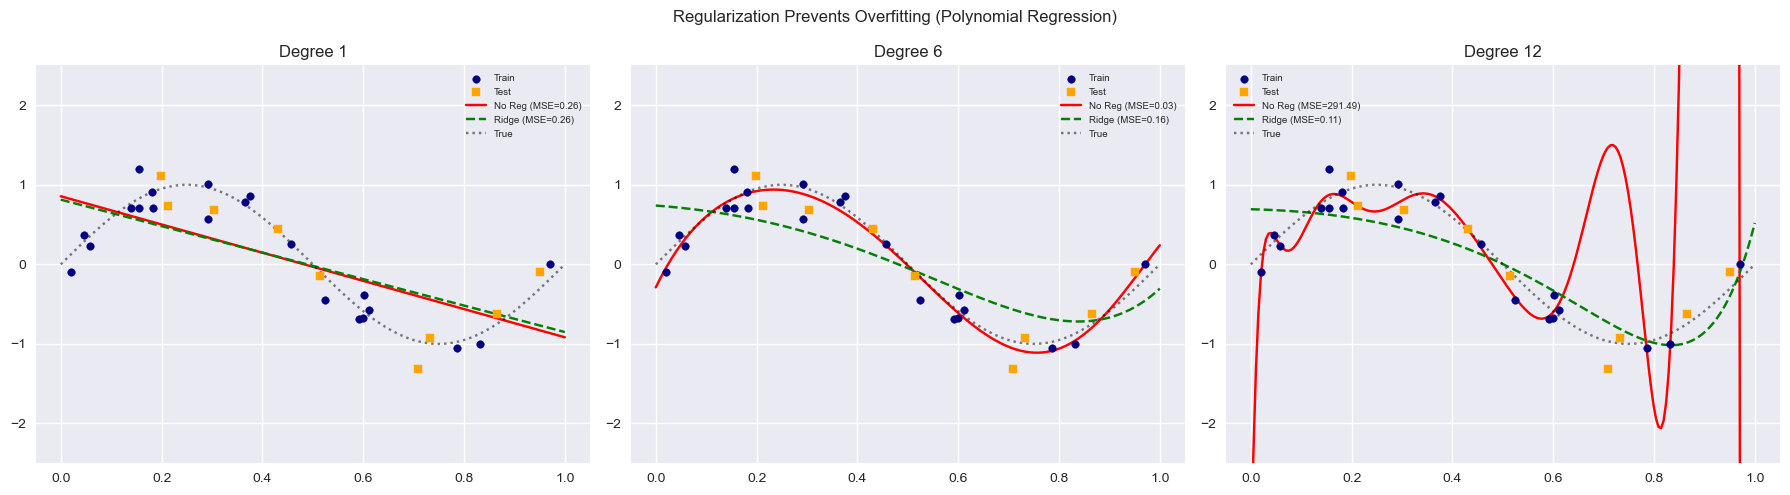

In [3]:
np.random.seed(42)
X = np.sort(np.random.rand(30, 1), axis=0)
y = np.sin(2 * np.pi * X.ravel()) + np.random.randn(30) * 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, degree in zip(axes, [1, 6, 12]):
    # Unregularized
    model = Pipeline([('poly', PolynomialFeatures(degree=degree)), ('lr', LinearRegression())])
    model.fit(X_train, y_train)
    train_mse = mean_squared_error(y_train, model.predict(X_train))
    test_mse = mean_squared_error(y_test, model.predict(X_test))

    # Regularized (Ridge)
    model_ridge = Pipeline([('poly', PolynomialFeatures(degree=degree)), 
                             ('ridge', Ridge(alpha=0.1))])
    model_ridge.fit(X_train, y_train)
    test_mse_ridge = mean_squared_error(y_test, model_ridge.predict(X_test))

    ax.scatter(X_train, y_train, c='navy', s=30, zorder=5, label='Train')
    ax.scatter(X_test, y_test, c='orange', s=30, zorder=5, marker='s', label='Test')
    ax.plot(X_plot, model.predict(X_plot), 'r-', label=f'No Reg (MSE={test_mse:.2f})')
    ax.plot(X_plot, model_ridge.predict(X_plot), 'g--', label=f'Ridge (MSE={test_mse_ridge:.2f})')
    ax.plot(X_plot, np.sin(2*np.pi*X_plot), 'k:', alpha=0.5, label='True')
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(f'Degree {degree}')
    ax.legend(fontsize=7)
    ax.grid(True)

plt.suptitle('Regularization Prevents Overfitting (Polynomial Regression)')
plt.tight_layout()
plt.show()

# 3. Comparing L1, L2, and Elastic Net

Key difference: **L1 drives weights to exactly 0** (feature selection), **L2 shrinks them smoothly** (never exact zero).

Comparing models with alpha=1.0:
Model                               MSE       Zero Coefs
No Regularization (OLS)             99.18    0/25
L2 - Ridge                          101.51    0/25
L1 - Lasso                          98.87    16/25
Elastic Net                         599.94    4/25


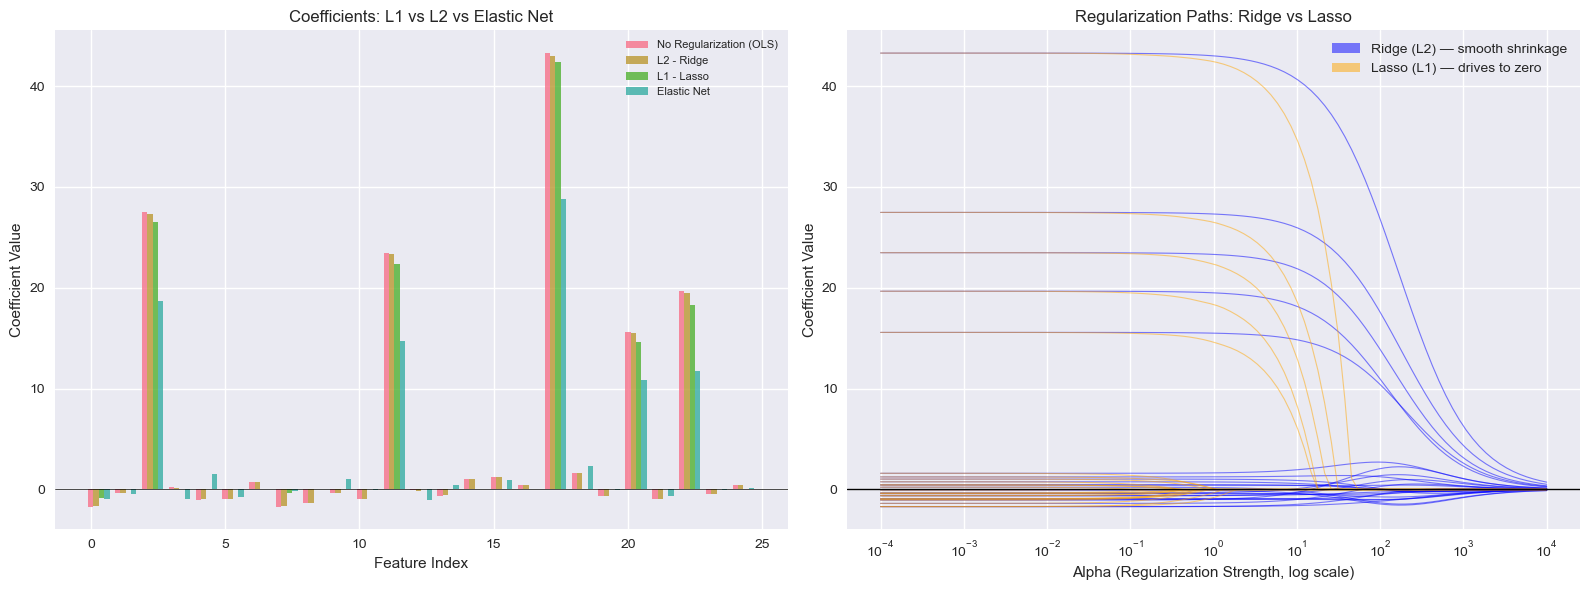

In [4]:
# Dataset: many features, only a few are truly informative
X_reg, y_reg, true_coef = make_regression(n_samples=200, n_features=25, 
                                            n_informative=5, noise=10, 
                                            coef=True, random_state=42)
X_reg_scaled = StandardScaler().fit_transform(X_reg)
X_tr, X_te, y_tr, y_te = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)

alpha = 1.0
models = {
    'No Regularization (OLS)': LinearRegression(),
    'L2 - Ridge': Ridge(alpha=alpha),
    'L1 - Lasso': Lasso(alpha=alpha, max_iter=10000),
    'Elastic Net': ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000),
}

coef_data = {}
print(f'Comparing models with alpha={alpha}:')
print(f'{"Model":<35} MSE       Zero Coefs')
for name, model in models.items():
    model.fit(X_tr, y_tr)
    mse = mean_squared_error(y_te, model.predict(X_te))
    coef = model.coef_
    n_zero = np.sum(np.abs(coef) < 1e-6)
    coef_data[name] = coef
    print(f'{name:<35} {mse:.2f}    {n_zero}/{len(coef)}')

# Visualize coefficients
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

width = 0.2
x_pos = np.arange(25)
for i, (name, coef) in enumerate(coef_data.items()):
    axes[0].bar(x_pos + i*width, coef, width=width, label=name, alpha=0.8)
axes[0].set_xlabel('Feature Index')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Coefficients: L1 vs L2 vs Elastic Net')
axes[0].legend(fontsize=8)
axes[0].grid(True, axis='y')
axes[0].axhline(y=0, color='k', linewidth=0.5)

# 2. Effect of lambda/alpha
alphas = np.logspace(-4, 4, 100)
ridge_coefs = [Ridge(alpha=a).fit(X_tr, y_tr).coef_ for a in alphas]
lasso_coefs = [Lasso(alpha=a, max_iter=10000).fit(X_tr, y_tr).coef_ for a in alphas]

for coef in np.array(ridge_coefs).T:
    axes[1].semilogx(alphas, coef, alpha=0.5, color='blue', linewidth=0.8)
for coef in np.array(lasso_coefs).T:
    axes[1].semilogx(alphas, coef, alpha=0.5, color='orange', linewidth=0.8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.5, label='Ridge (L2) — smooth shrinkage'),
                   Patch(facecolor='orange', alpha=0.5, label='Lasso (L1) — drives to zero')]
axes[1].legend(handles=legend_elements)
axes[1].set_xlabel('Alpha (Regularization Strength, log scale)')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Regularization Paths: Ridge vs Lasso')
axes[1].grid(True)
axes[1].axhline(y=0, color='k', linewidth=1)

plt.tight_layout()
plt.show()

# 4. Early Stopping — Regularization for Neural Networks

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (4) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_pe

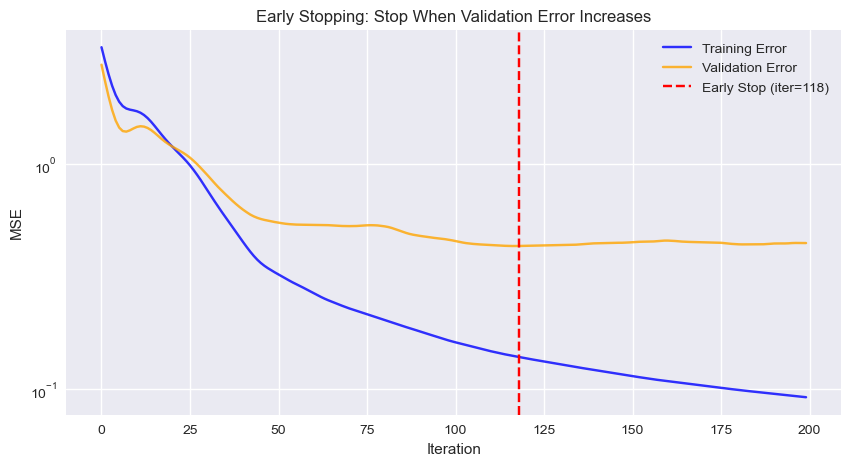

Best iteration: 118
Validation MSE at best iter: 0.4326
Validation MSE at 200 iters: 0.4459

=== Regularization Summary ===
  L1 (Lasso)      → Feature selection needed, sparse model   | API: sklearn.linear_model.Lasso
  L2 (Ridge)      → All features matter, prevent overfitting | API: sklearn.linear_model.Ridge
  Elastic Net     → Correlated features + sparsity           | API: sklearn.linear_model.ElasticNet
  Dropout         → Deep neural networks                     | API: keras.layers.Dropout()
  Early Stopping  → Any iterative model                      | API: MLPRegressor(early_stopping=True)


In [5]:
# Train with early stopping using sklearn's MLPRegressor
X_nn = np.random.randn(200, 5)
y_nn = X_nn[:, 0] ** 2 + 0.5 * X_nn[:, 1] + np.random.randn(200) * 0.5

X_nn_tr, X_nn_val, y_nn_tr, y_nn_val = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42)

# Without early stopping: more iterations → overfitting
train_errors, val_errors = [], []
for n_iter in range(1, 201):
    mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=n_iter, 
                        random_state=42, warm_start=True, learning_rate_init=0.01)
    mlp.fit(X_nn_tr, y_nn_tr)
    train_errors.append(mean_squared_error(y_nn_tr, mlp.predict(X_nn_tr)))
    val_errors.append(mean_squared_error(y_nn_val, mlp.predict(X_nn_val)))

best_iter = np.argmin(val_errors) + 1

plt.figure(figsize=(10, 5))
plt.plot(train_errors, label='Training Error', color='blue', alpha=0.8)
plt.plot(val_errors, label='Validation Error', color='orange', alpha=0.8)
plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Early Stop (iter={best_iter})')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Early Stopping: Stop When Validation Error Increases')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

print(f'Best iteration: {best_iter}')
print(f'Validation MSE at best iter: {val_errors[best_iter-1]:.4f}')
print(f'Validation MSE at 200 iters: {val_errors[-1]:.4f}')

print('\n=== Regularization Summary ===')
regularization_guide = [
    ('L1 (Lasso)', 'Feature selection needed, sparse model', 'sklearn.linear_model.Lasso'),
    ('L2 (Ridge)', 'All features matter, prevent overfitting', 'sklearn.linear_model.Ridge'),
    ('Elastic Net', 'Correlated features + sparsity', 'sklearn.linear_model.ElasticNet'),
    ('Dropout', 'Deep neural networks', 'keras.layers.Dropout()'),
    ('Early Stopping', 'Any iterative model', 'MLPRegressor(early_stopping=True)'),
]

for reg_type, use_when, sklearn_api in regularization_guide:
    print(f'  {reg_type:<15} → {use_when:<40} | API: {sklearn_api}')

# Conclusions and Key Takeaways
Regularization is a technique used to shrink the coefficients of a model towards zero to discourage complex models and prevent overfitting.
- **L1 (Lasso)**: Adds absolute magnitude of coefficient to the penalty. Can shrink coefficients to exactly zero, hence it performs automatic feature selection.
- **L2 (Ridge)**: Adds squared magnitude of coefficient as a penalty. Shrinks coefficients evenly but doesn't set them exactly to zero.
- **Elastic Net**: A combination of L1 and L2 regularization.

# Pros and Cons
**Pros:**
- Effectively prevents overfitting and improves model generalization to new data.
- Lasso can be extremely useful for feature selection in datasets with a high number of features.
- Stabilizes coefficient estimates, especially when features are highly collinear.

**Cons:**
- Requires tuning of the regularization parameter (lambda/alpha).
- Ridge does not completely remove features, bringing a computational cost if there are millions of features.
- Can introduce a slight bias to the estimates in exchange for heavily reduced variance.

# 15 Interview Questions and Answers

1. **What is Regularization?**
   *Answer*: A technique used to calibrate machine learning models to minimize the adjusted loss function and prevent overfitting or underfitting. It achieves this by adding a penalty term to the error function.

2. **Why do we need Regularization?**
   *Answer*: To reduce the variance of the model and prevent overfitting, leading to better generalization on unseen data.

3. **What is Ridge Regression (L2 Regularization)?**
   *Answer*: It adds a penalty equivalent to the square of the magnitude of coefficients. The regularization term is lambda * Σ(weights²).

4. **What is Lasso Regression (L1 Regularization)?**
   *Answer*: It adds a penalty equivalent to the absolute value of the magnitude of coefficients. The regularization term is lambda * Σ|weights|.

5. **What is the key difference between Ridge and Lasso?**
   *Answer*: Lasso can shrink coefficients of less important features to exactly zero, thus removing them and acting as a feature selector. Ridge only shrinks them close to zero but keeps all features.

6. **When would you use Ridge over Lasso?**
   *Answer*: Ridge is preferable when most of the features are useful and you want to keep them all but reduce their impact to prevent overfitting. It handles multicollinearity well.

7. **When would you use Lasso over Ridge?**
   *Answer*: Lasso is better when you have a lot of useless or redundant features and you want a simpler, more interpretable model with fewer features.

8. **What is Elastic Net?**
   *Answer*: A middle ground between Ridge and Lasso. It combines the L1 and L2 penalties: alpha * (L1 penalty) + (1-alpha) * (L2 penalty).

9. **Why use Elastic Net instead of just Lasso?**
   *Answer*: When there are highly correlated variables, Lasso tends to select just one of them randomly and discard the others. Elastic Net overcomes this by utilizing the L2 penalty to help keep groups of correlated variables together.

10. **What is the regularization hyperparameter (lambda or alpha)?**
    *Answer*: It controls the strength of the penalty. If lambda is 0, the model is equivalent to unregularized regression. If lambda is very high, coefficients approach zero, leading to underfitting.

11. **How do you find the optimal value for the regularization parameter?**
    *Answer*: By using cross-validation (e.g., RidgeCV or LassoCV in scikit-learn). You test various values on an exponential scale (e.g., 0.01, 0.1, 1, 10, 100) and pick the one with the lowest cross-validation error.

12. **Should you scale your data before applying Regularization?**
    *Answer*: Yes, this is absolutely necessary. Since regularization penalizes the size of the coefficients, features on larger scales will be penalized more heavily than features on smaller scales if they are not standardized first.

13. **Can regularization be used in Neural Networks?**
    *Answer*: Yes, L1 and L2 weight decay are common. Other techniques like Dropout and Early Stopping are also forms of regularization used specifically in deep learning.

14. **What does the geometry of L1 vs L2 look like?**
    *Answer*: The L1 constraint forms a diamond shape in 2D space, which has sharp corners on the axes. The loss function is very likely to hit a corner, zeroing out a coefficient. The L2 constraint forms a circle, which has no sharp corners, so it rarely hits exactly zero.

15. **Does regularization help with the bias-variance tradeoff?**
    *Answer*: Yes, it explicitly targets the tradeoff. By increasing the penalty (lambda), you increase bias slightly but vastly reduce variance, moving the model toward the optimal tradeoff point.
